<a href="https://colab.research.google.com/github/Sieraiu/company-directory-scraper/blob/main/Proje_1_Company_Directory_Scraper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Company Directory Scraper

This Python project collects company names, websites, and LinkedIn URLs from a directory website.
The data is cleaned and saved into a CSV file for analysis or further use.

## Tools Used:
- Python
- Requests
- BeautifulSoup
- CSV

## How It Works:
1. Send a request to the target website
2. Parse the HTML content
3. Extract company name, website, LinkedIn
4. Save the results to a CSV file

## Sample Output:
| Company Name | Website | LinkedIn |
|-------------|--------|----------|
| ABC Corp    | www.abccorp.com | linkedin.com/company/abc |

## Importing Required Libraries

In this step, we import the libraries required for web scraping and data manipulation.

- **requests** is used to send HTTP requests to the website.
- **BeautifulSoup** is used to parse and navigate the HTML structure of the webpage.
- **pandas** is used to organize the scraped data into a structured dataset.

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

## Defining the Target Website

Here we define the base URL of the website we want to scrape.

This URL will be used to access the book catalogue pages where book information is listed.

In [ ]:
url = 'https://books.toscrape.com'
response = requests.get(url)
print(response.status_code)
print(response.text[:500])

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


## Extracting Book Elements

We parse the HTML content using BeautifulSoup and extract all book containers.

Each book is represented by an `<article>` tag, and `find_all('article')` returns a list of all books on the page.

In [ ]:
soup = BeautifulSoup(response.text,'html.parser')
books = soup.find_all('article')



In [ ]:
for book in books:
 print(book)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>
<article class="product_pod">
<div class="image_container">
<a href="catalogue/tipping-the-velvet_999/index.html"><img alt="Tipping the Velvet" class="thumbnail" src="media/cache/26/

## Extracting Book Titles

In this step, we iterate through each book element.

- Each book contains a title inside the `<h3>` tag.
- The actual title is stored in the `title` attribute of the `<a>` tag.

We extract the title and print it for verification.


In [ ]:
for book in books:
  name = book.h3.a['title']
  print(name)

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


## Extracting Prices

We extract the price of each book by locating the `<p>` tag with the class `price_color` and print it.

In [ ]:
for book in books:
   price = book.find( "p", class_= 'price_color').text
   print(price)

Â£51.77
Â£53.74
Â£50.10
Â£47.82
Â£54.23
Â£22.65
Â£33.34
Â£17.93
Â£22.60
Â£52.15
Â£13.99
Â£20.66
Â£17.46
Â£52.29
Â£35.02
Â£57.25
Â£23.88
Â£37.59
Â£51.33
Â£45.17


## Extracting Title and Price

We loop through each book and extract both the title and price, then print them together.

In [ ]:
for book in books:
   price = book.find( "p", class_= 'price_color').text
   name = book.h3.a['title']
   print(name,price)

A Light in the Attic Â£51.77
Tipping the Velvet Â£53.74
Soumission Â£50.10
Sharp Objects Â£47.82
Sapiens: A Brief History of Humankind Â£54.23
The Requiem Red Â£22.65
The Dirty Little Secrets of Getting Your Dream Job Â£33.34
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics Â£22.60
The Black Maria Â£52.15
Starving Hearts (Triangular Trade Trilogy, #1) Â£13.99
Shakespeare's Sonnets Â£20.66
Set Me Free Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) Â£52.29
Rip it Up and Start Again Â£35.02
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 Â£57.25
Olio Â£23.88
Mesaerion: The Best Science Fiction Stories 1800-1849 Â£37.59
Libertarianism for Beginners Â£51.33
It's Only the Himalayas Â£45.17


## Looping Through Pages

We iterate over multiple pages by dynamically generating URLs and extracting book elements from each page.

In [ ]:
for page in range(1,6):
  url = f'https://books.toscrape.com/catalogue/page-{page}.html'
  response = requests.get(url)
  soup = BeautifulSoup(response.text,'html.parser')
  books = soup.find_all('article')


## Extracting Data from Multiple Pages

We loop through all pages and extract book titles and prices from each page.

In [ ]:
for page in range(1, 6):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article")
    for book in books:
        price = book.find( "p", class_= 'price_color').text
        name = book.h3.a['title']
        print(name,price)

A Light in the Attic Â£51.77
Tipping the Velvet Â£53.74
Soumission Â£50.10
Sharp Objects Â£47.82
Sapiens: A Brief History of Humankind Â£54.23
The Requiem Red Â£22.65
The Dirty Little Secrets of Getting Your Dream Job Â£33.34
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics Â£22.60
The Black Maria Â£52.15
Starving Hearts (Triangular Trade Trilogy, #1) Â£13.99
Shakespeare's Sonnets Â£20.66
Set Me Free Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) Â£52.29
Rip it Up and Start Again Â£35.02
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 Â£57.25
Olio Â£23.88
Mesaerion: The Best Science Fiction Stories 1800-1849 Â£37.59
Libertarianism for Beginners Â£51.33
It's Only the Himalayas Â£45.17
In Her Wake Â£12.84
How Music Works Â£37.32
Foolproof Preserving: A Guide to Small Batch Jams, Jellies, Pickles, 

## Extracting Ratings

Book ratings are stored as class names. We extract the second class value to get the rating (e.g., One, Two, Three).

In [ ]:
for book in books :
  rate = book.find ('p',class_ = 'star-rating')['class'][1]
  print(rate)

Five
Five
One
Two
Three
Four
One
One
Three
Two
Two
Two
Four
Two
Three
Two
One
Two
Five
Four


## Extracting Stock Availability

We extract stock status from the relevant `<p>` tag and clean the text using `.strip()`.

In [ ]:
for book in books:
  In_stock = book.find('p',class_ = 'instock availability').text.strip()
  print(In_stock)

In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock
In stock


## Defining Base URL

We define the base URL to construct full links for each book's detail page.

In [ ]:
for book in books:
  base_url = "https://books.toscrape.com/catalogue/"
  href = book.h3.a["href" ]
  print(href)

princess-jellyfish-2-in-1-omnibus-vol-01-princess-jellyfish-2-in-1-omnibus-1_920/index.html
princess-between-worlds-wide-awake-princess-5_919/index.html
pop-gun-war-volume-1-gift_918/index.html
political-suicide-missteps-peccadilloes-bad-calls-backroom-hijinx-sordid-pasts-rotten-breaks-and-just-plain-dumb-mistakes-in-the-annals-of-american-politics_917/index.html
patience_916/index.html
outcast-vol-1-a-darkness-surrounds-him-outcast-1_915/index.html
orange-the-complete-collection-1-orange-the-complete-collection-1_914/index.html
online-marketing-for-busy-authors-a-step-by-step-guide_913/index.html
on-a-midnight-clear_912/index.html
obsidian-lux-1_911/index.html
my-paris-kitchen-recipes-and-stories_910/index.html
masks-and-shadows_909/index.html
mama-tried-traditional-italian-cooking-for-the-screwed-crude-vegan-and-tattooed_908/index.html
lumberjanes-vol-2-friendship-to-the-max-lumberjanes-5-8_907/index.html
lumberjanes-vol-1-beware-the-kitten-holy-lumberjanes-1-4_906/index.html
lumberj

## Building the Scraper and Creating Dataset

In this step, we combine all previous steps:

- Loop through pages
- Extract book details (title, price, rating, stock, link)
- Store the data in a list of dictionaries

Finally, we convert the data into a pandas DataFrame and export it as a CSV file.

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

data = []

for page in range(1,6):
    url = f'https://books.toscrape.com/catalogue/page-{page}.html'
    response = requests.get(url)
    soup = BeautifulSoup(response.text,'html.parser')
    books = soup.find_all('article')

    for book in books:
        name= book.h3.a['title']
        price = book.find("p", class_='price_color').text
        rate = book.find('p', class_='star-rating')['class'][1]
        In_stock = book.find('p', class_='instock availability').text.strip()
        href = book.h3.a['href']

        data.append({
            'name': name,
            'price': price,
            'rate': rate,
            'In_stock': In_stock,
            'href': href
        })

df = pd.DataFrame(data)


## Cleaning Price Data

We remove the currency symbol from the price column and convert the values to float for analysis.

In [ ]:
df["price"] = df["price"].str.replace('Â£','').astype(float)

In [ ]:
df.head()

,name,price,rate,In_stock,href
0,A Light in the Attic,51.77,Three,In stock,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,In stock,tipping-the-velvet_999/index.html
2,Soumission,50.10,One,In stock,soumission_998/index.html
3,Sharp Objects,47.82,Four,In stock,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,sapiens-a-brief-history-of-humankind_996/index...


## Finding Most Expensive Books

We sort the dataset by price in descending order to identify the most expensive books.

In [ ]:
df.sort_values(by = "price" , ascending = False).head()

,name,price,rate,In_stock,href
68,The Death of Humanity: and the Case for Life,58.11,Four,In stock,the-death-of-humanity-and-the-case-for-life_93...
40,Slow States of Collapse: Poems,57.31,Three,In stock,slow-states-of-collapse-poems_960/index.html
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three,In stock,our-band-could-be-your-life-scenes-from-the-am...
58,The Past Never Ends,56.50,Four,In stock,the-past-never-ends_942/index.html
57,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41,One,In stock,the-pioneer-woman-cooks-dinnertime-comfort-cla...


## Visualizing Rating Distribution

We visualize the distribution of book ratings using a bar chart to better understand how ratings are spread across the dataset.

<Axes: xlabel='rate'>

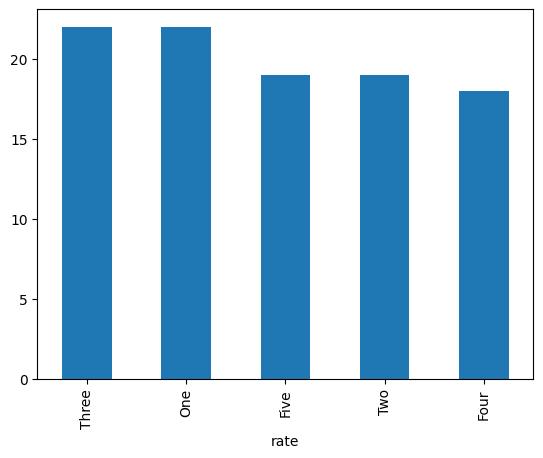

In [ ]:
df["rate"].value_counts().plot(kind="bar")

## Creating Full Product Links

We combine the base URL with the relative link (`href`) to construct the full URL for each book's detail page.

In [ ]:
base_url = "https://books.toscrape.com/catalogue/"
full_link = base_url + href

## Extracting Book Description

We send a request to the book's detail page and extract the description from the meta tag.

In [ ]:
response = requests.get(full_link)
soup = BeautifulSoup(response.text,"html.parser")
description = soup.find("meta", attrs={"name":"description"})["content"]

## Checking for Next Page

We check whether a "next" button exists to determine if there are more pages to scrape.

In [ ]:
next_button = soup.find("li", class_="next")
print(next_button)

None


## Scraping with Automatic Pagination

We use a `while` loop to automatically navigate through all pages.

- The scraper continues as long as a "next" button exists
- When no next page is found, the loop stops

This approach allows us to scrape the entire website without manually specifying page numbers.

In [ ]:
url = "https://books.toscrape.com/catalogue/page-1.html"

while True:

    response = requests.get(url)
    soup = BeautifulSoup(response.text,"html.parser")

    books = soup.find_all("article")

    for book in books:
        name = book.h3.a["title"]
        print(name)

    next_button = soup.find("li", class_="next")

    if next_button:
        next_page = next_button.a["href"]
        url = "https://books.toscrape.com/catalogue/" + next_page
    else:
        break

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas
In Her Wake
How Music Works
Foolproof Preserving: A Guide to Small Batch Jams, Jellies, Pickles, Condiments, and More: A Foolproof Guide to Making Small Batch Jams, Jellies, Pickles, Condiments, and More
Chase Me (Paris Nights #2)
Black Dust
Birdsong: A Story in Pictures
A

## Cleaning Price Column

We convert the price column to string, remove the currency symbol, and convert it to float for numerical analysis.

In [ ]:
df["price"] = df["price"].astype(str).str.replace("Â£","").astype(float)

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# 1. Retry ve Session Ayarları (Bağlantı koparsa tekrar denemesi için)
session = requests.Session()
# connect=5: Bağlantı reddedilirse 5 kere daha dener.
# backoff_factor=1: Denemeler arasında bekleme süresini katlayarak artırır (1s, 2s, 4s...)
retry = Retry(connect=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])
adapter = HTTPAdapter(max_retries=retry)
session.mount('http://', adapter)
session.mount('https://', adapter)

# 2. Tarayıcı kimliği (User-Agent) eklemek
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

data = []
base_url = "https://books.toscrape.com/catalogue/"
url = "https://books.toscrape.com/catalogue/page-1.html"

while True:
    try:
        # requests.get yerine session.get kullanıyoruz
        response = session.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")
    except Exception as e:
        print(f"Ana sayfa yüklenirken hata oluştu ({url}): {e}")
        break # Ana sayfaya ulaşılamıyorsa döngüyü kır

    books = soup.find_all("article")

    for book in books:
        # Basic info
        name = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rate = book.find("p", class_="star-rating")["class"][1]
        stock = book.find("p", class_="instock availability").text.strip()
        href = book.h3.a["href"]

        full_link = base_url + href
        description = "No description" # Varsayılan değer

        # 3. Detay sayfası için Try-Except bloğu
        try:
            detail_response = session.get(full_link, headers=headers, timeout=10)
            soup_detail = BeautifulSoup(detail_response.text, "html.parser")

            desc_tag = soup_detail.find("meta", attrs={"name": "description"})
            if desc_tag and desc_tag["content"].strip():
                description = desc_tag["content"].strip()

        except Exception as e:
            # Eğer hata verirse program çökmez, sadece bu kitabı loglar ve diğerine geçer
            print(f"Detay sayfası çekilemedi ({name}): {e}")

        # Append data
        data.append({
            "name": name,
            "price": price,
            "rate": rate,
            "stock": stock,
            "link": full_link,
            "description": description
        })

        time.sleep(0.5)

    print(f"Taranan sayfa URL'si tamamlandı: {url}")

    # Pagination
    next_button = soup.find("li", class_="next")
    if next_button:
        next_page = next_button.a["href"]
        url = base_url + next_page
    else:
        break

# CSV Kaydetme
df = pd.DataFrame(data)
df.to_csv("books.csv", index=False, encoding="utf-8-sig")

print("CSV başarıyla oluşturuldu!")

Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-1.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-2.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-3.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-4.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-5.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-6.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-7.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-8.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-9.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-10.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-11.html
Taranan sayfa URL'si tamamlandı: https://books.toscrape.com/catalogue/page-12.html
Taranan sayfa

In [ ]:
from google.colab import files
files.download("books.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>